# 2. Train the surrogate and compare it with the baselines

Reads the committed results. Nothing here recomputes a number that appears in
the documentation — the tables *are* the evidence, and this notebook reads
them so a figure can never disagree with a table.

Regenerate with `python scripts/compare_methods.py --config configs/base.yaml`.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "2")
import sys
sys.path.insert(0, "../src")
import numpy as np, pandas as pd, torch
torch.set_num_threads(2)
import matplotlib.pyplot as plt
pd.set_option("display.width", 130)


In [2]:
T = '../results/tables/'
methods = pd.read_csv(T+'method_comparison.csv')
print(f"{methods.method.nunique()} methods x {methods.split.nunique()} splits")
cols = ['split','method','mae','rmse','spearman_pooled','spearman_within_scenario','top1_agreement']
methods.loc[methods.split=='test_id', cols].round(4).to_string(index=False)

10 methods x 7 splits


'  split                 method    mae   rmse  spearman_pooled  spearman_within_scenario  top1_agreement\ntest_id     surrogate_ensemble 0.0153 0.0554           0.3536                    0.5715          0.5208\ntest_id       surrogate_single 0.0146 0.0531           0.3567                    0.5824          0.5833\ntest_id mlp_no_message_passing 0.0174 0.0685           0.2671                    0.4018          0.2292\ntest_id            tabular_gbt 0.0104 0.0366           0.4115                    0.6867          0.7292\ntest_id         tabular_gbt_l1 0.0122 0.0696              NaN                       NaN          0.1250\ntest_id          tabular_ridge 0.0246 0.0616           0.3526                    0.4866          0.4583\ntest_id          retrieval_knn 0.0106 0.0412           0.5078                    0.7368          0.6458\ntest_id     topology_heuristic 0.0240 0.0668           0.2321                    0.3486          0.1250\ntest_id          constant_zero 0.0122 0.0696          

## Magnitude error and rank fidelity are different questions

The target is **92.48% exact zeros**, so the MAE-optimal predictor is the
constant **0** — and a model that collapses to it posts the best MAE in the
table while being useless for screening. That is not hypothetical: this
repository shipped it for 43 commits. `constant_zero` and
`constant_train_mean` are therefore run as first-class methods, and
`tabular_gbt_l1` — the same trees under `absolute_error` — is numerically
identical to `constant_zero` on every metric on every split. See
`docs/RESULTS.md` §8.7.

Rank fidelity is the metric that matters for the actual task, and a constant
cannot win it at all (its Spearman is undefined). The two columns below can
disagree sharply.

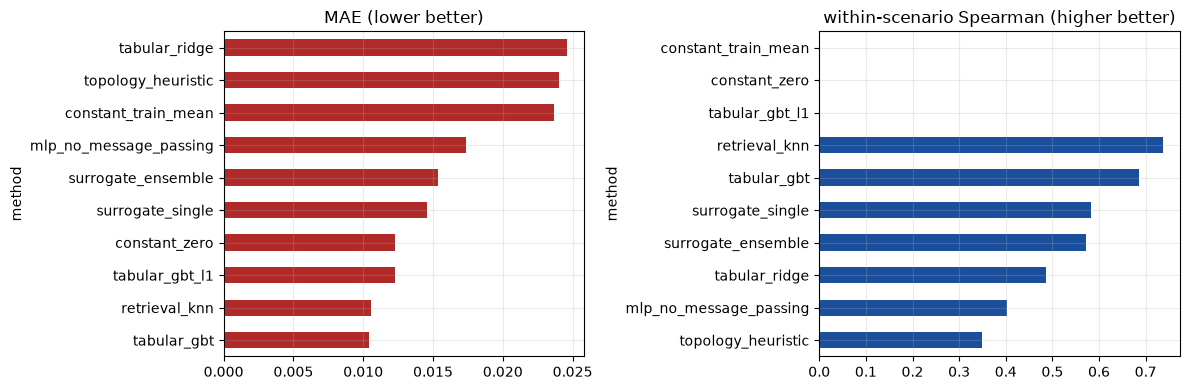

In [3]:
sub = methods[methods.split=='test_id'].set_index('method')
fig, axes = plt.subplots(1,2, figsize=(12,4))
sub['mae'].sort_values().plot.barh(ax=axes[0], color='#b02a2a')
axes[0].set_title('MAE (lower better)')
sub['spearman_within_scenario'].sort_values().plot.barh(ax=axes[1], color='#1b4f9c')
axes[1].set_title('within-scenario Spearman (higher better)')
for a in axes: a.grid(alpha=.25)
plt.tight_layout(); plt.show()

## Generalisation along each shift axis

Each split changes exactly one thing relative to `test_id`, which is what makes
a gap attributable.

In [4]:
gen = pd.read_csv(T+'generalisation.csv')
gen.round(4).to_string(index=False)

'                method  test_id_mae  shift_topo_mae  shift_size_mae  shift_type_mae  shift_multi_mae  shift_topo_gap  shift_size_gap  shift_type_gap  shift_multi_gap  test_id_spearman  shift_topo_spearman  shift_size_spearman  shift_type_spearman  shift_multi_spearman\n    surrogate_ensemble       0.0153          0.0176          0.0186          0.0103           0.0356          0.0023          0.0033         -0.0051           0.0203            0.3536               0.4096               0.3925               0.3162                0.5163\n      surrogate_single       0.0146          0.0172          0.0183          0.0098           0.0343          0.0027          0.0037         -0.0048           0.0197            0.3567               0.4191               0.3879               0.3309                0.5351\nmlp_no_message_passing       0.0174          0.0190          0.0196          0.0109           0.0402          0.0016          0.0022         -0.0065           0.0228            0.2671      

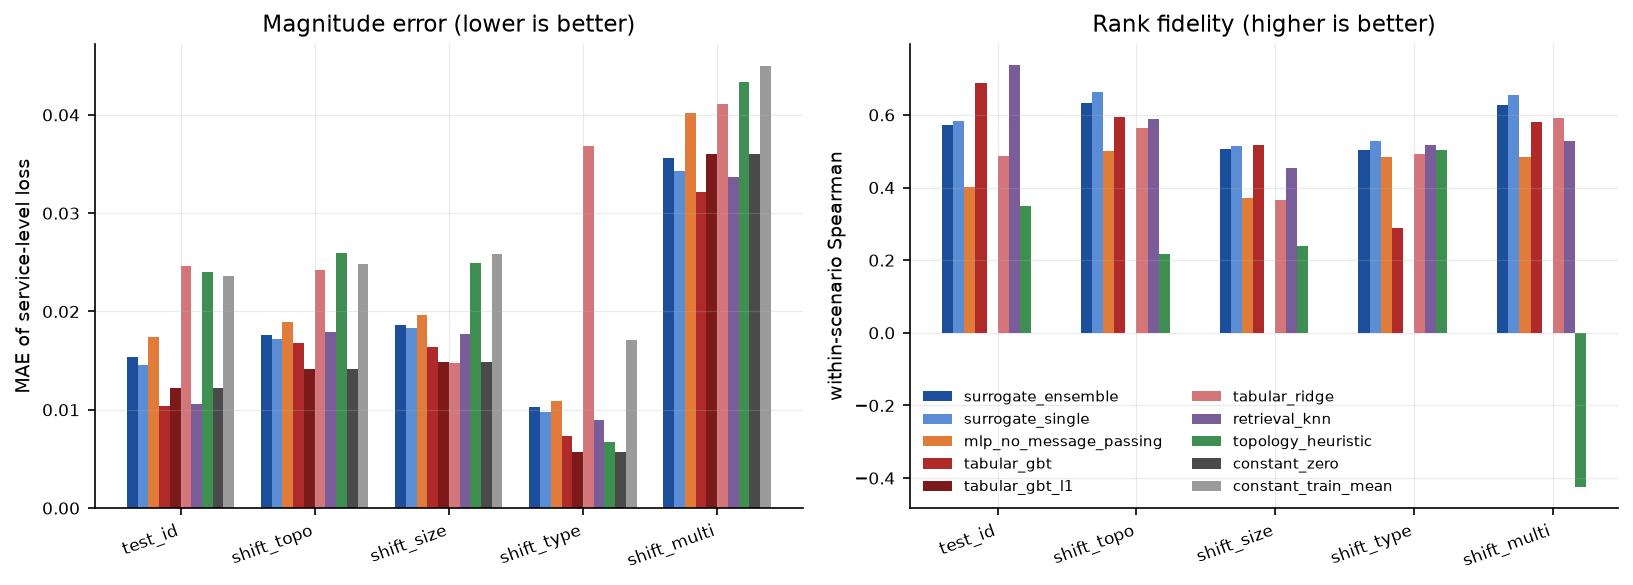

In [5]:
from IPython.display import Image, display
import os
if os.path.exists('../results/figures/generalisation.png'):
    display(Image(filename='../results/figures/generalisation.png'))

## Is any difference real?

Paired per-row Wilcoxon with Holm-Bonferroni, against the reference-style
tabular model. **This conditions on one trained model per method** — it answers
a question about two sets of weights, not about two methods. The method-level
question needs the seed study in notebook 3.

In [6]:
st = pd.read_csv(T+'statistical_tests.csv')
s = st[st.split=='test_id'][['name_a','mean_a','mean_b','difference','ci_lower','ci_upper','p_adjusted','effect_size','significant']]
s.round(5).to_string(index=False)

'                          name_a  mean_a  mean_b  difference  ci_lower  ci_upper  p_adjusted  effect_size  significant\n    surrogate_ensemble.abs_error 0.01534 0.01042     0.00492   0.00299   0.00706         0.0      0.11819         True\n      surrogate_single.abs_error 0.01458 0.01042     0.00416   0.00227   0.00617         0.0      0.10412         True\nmlp_no_message_passing.abs_error 0.01740 0.01042     0.00698   0.00452   0.00981         0.0      0.13121         True\n        tabular_gbt_l1.abs_error 0.01225 0.01042     0.00183  -0.00072   0.00473         0.0      0.03326         True\n         tabular_ridge.abs_error 0.02461 0.01042     0.01419   0.01220   0.01645         0.0      0.33476         True\n         retrieval_knn.abs_error 0.01055 0.01042     0.00013  -0.00114   0.00140         0.0      0.00526         True\n    topology_heuristic.abs_error 0.02399 0.01042     0.01358   0.01128   0.01623         0.0      0.26974         True\n         constant_zero.abs_error 0.0122